Let's load some packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

Let's load the data.

In [2]:
rainfall_train = pd.read_csv('/kaggle/input/playground-series-s5e3/train.csv',index_col = 'id')
rainfall_test = pd.read_csv('/kaggle/input/playground-series-s5e3/test.csv',index_col='id')

Let's check out the data.

In [3]:
rainfall_train.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
id,,,,,,,,,,,,
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [4]:
rainfall_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            2190 non-null   int64  
 1   pressure       2190 non-null   float64
 2   maxtemp        2190 non-null   float64
 3   temparature    2190 non-null   float64
 4   mintemp        2190 non-null   float64
 5   dewpoint       2190 non-null   float64
 6   humidity       2190 non-null   float64
 7   cloud          2190 non-null   float64
 8   sunshine       2190 non-null   float64
 9   winddirection  2190 non-null   float64
 10  windspeed      2190 non-null   float64
 11  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 222.4 KB


The dataset is on the smaller side and contains solely numerical data. Also there are no missing values.

In [5]:
rainfall_train.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


Let's check out the correlation matrix.

<Axes: >

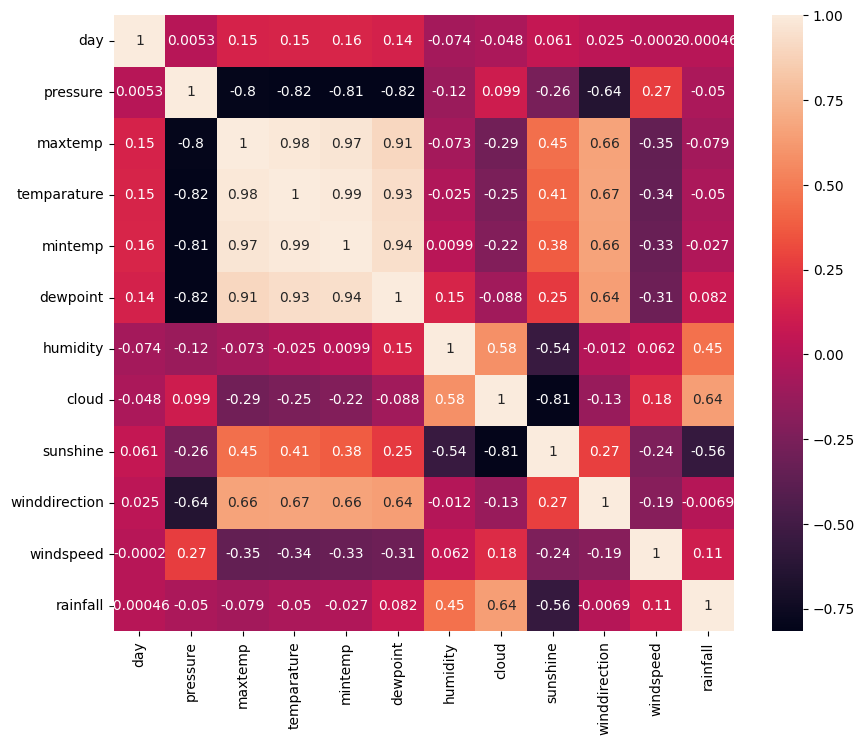

In [6]:
corr = rainfall_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(data=corr,annot=True)

In [7]:
corr['rainfall'].sort_values(ascending=False)

rainfall         1.000000
cloud            0.641191
humidity         0.454213
windspeed        0.111625
dewpoint         0.081965
day             -0.000462
winddirection   -0.006939
mintemp         -0.026841
temparature     -0.049660
pressure        -0.049886
maxtemp         -0.079304
sunshine        -0.555287
Name: rainfall, dtype: float64

'cloud' and 'humidity' have a strong positive correlation with rainfall which makes sense. 'sunshine' has a strong negative correlation. 'temparature' has a spelling typo, but more importantly, the features 'temparature', 'maxtemp', 'mintemp' and 'dewpoint' are highly correlated with each other which can lead to multicollinearity issues. The features 'cloud' and 'sunshine' have a strong negative correlation. The same is true with 'dewpoint' and 'pressure'. We can consider dropping these features as well.

Let's plot the data.

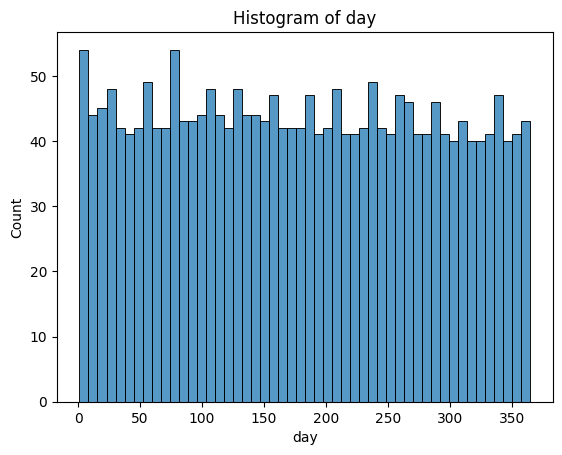

<Figure size 640x480 with 0 Axes>

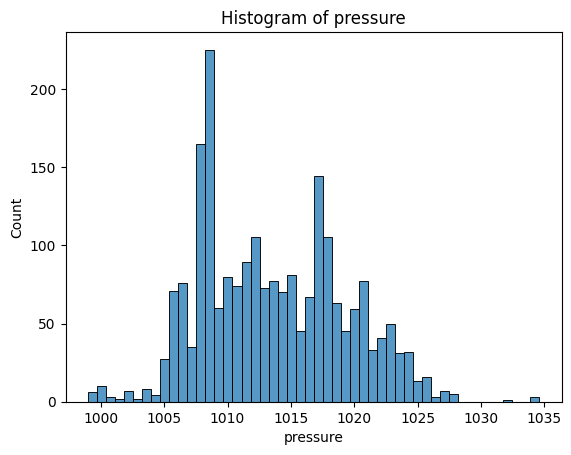

<Figure size 640x480 with 0 Axes>

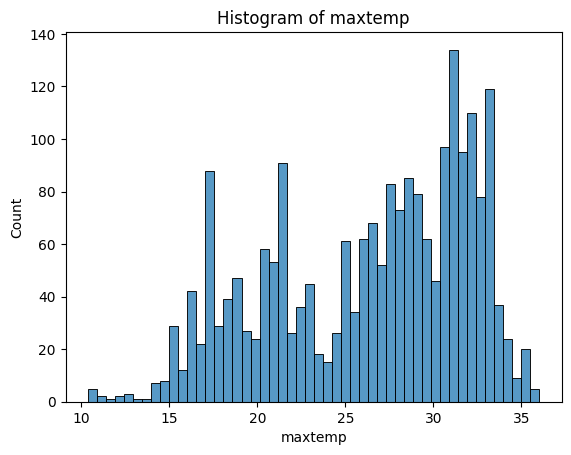

<Figure size 640x480 with 0 Axes>

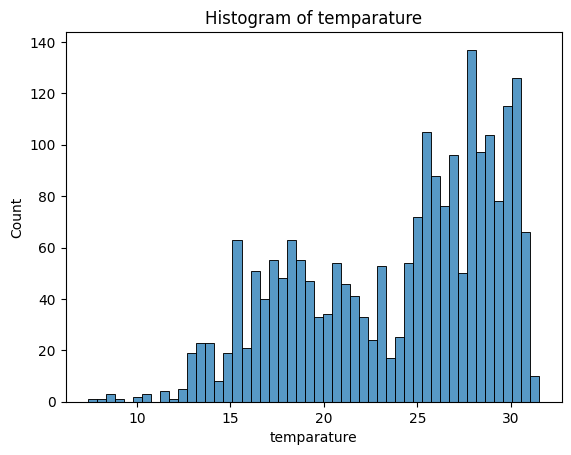

<Figure size 640x480 with 0 Axes>

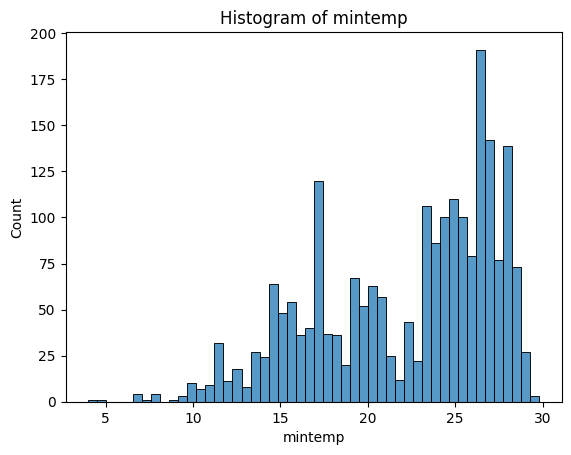

<Figure size 640x480 with 0 Axes>

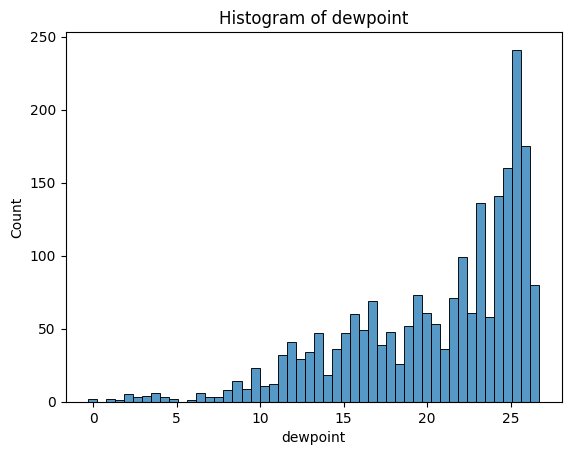

<Figure size 640x480 with 0 Axes>

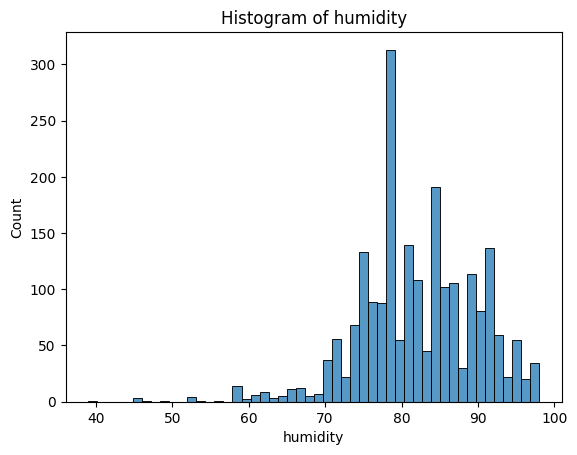

<Figure size 640x480 with 0 Axes>

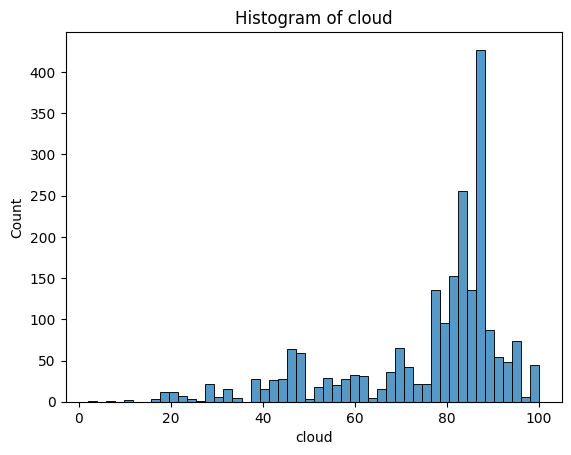

<Figure size 640x480 with 0 Axes>

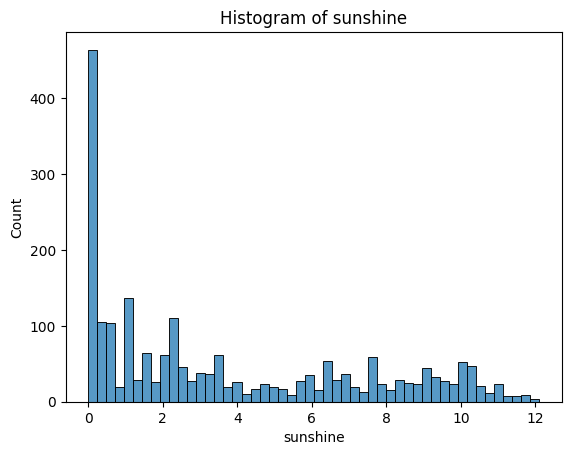

<Figure size 640x480 with 0 Axes>

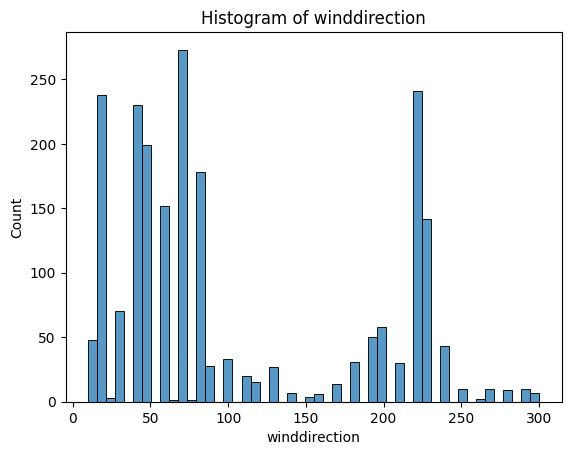

<Figure size 640x480 with 0 Axes>

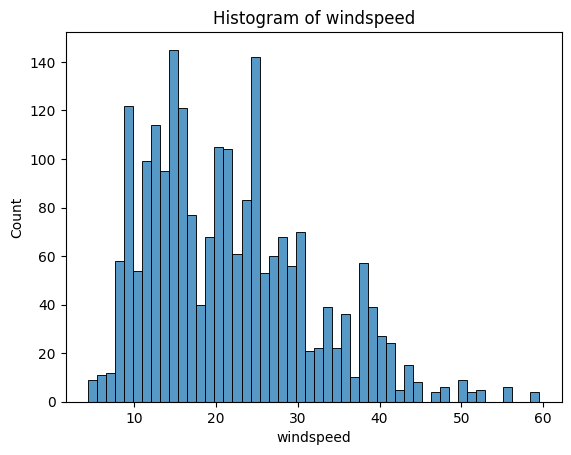

<Figure size 640x480 with 0 Axes>

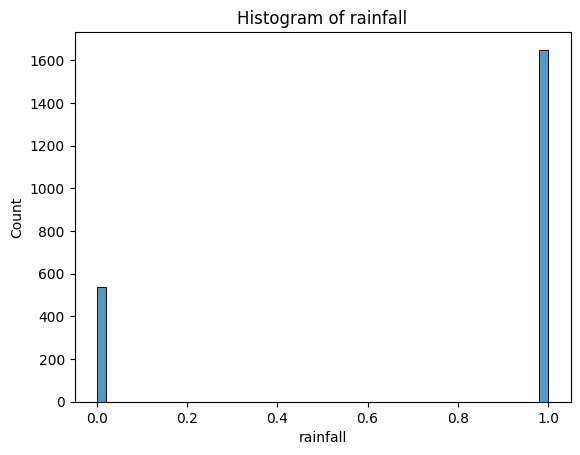

<Figure size 640x480 with 0 Axes>

In [8]:
for col in rainfall_train.columns:
    plt.figure()
    sns.histplot(data=rainfall_train,x=col,bins=50)
    plt.title(f"Histogram of {col}")
    plt.show()
    plt.clf()

Let's color the above plots by whether or not there was rain.

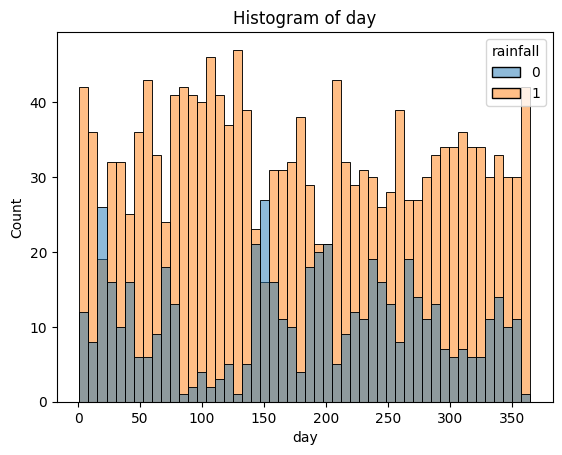

<Figure size 640x480 with 0 Axes>

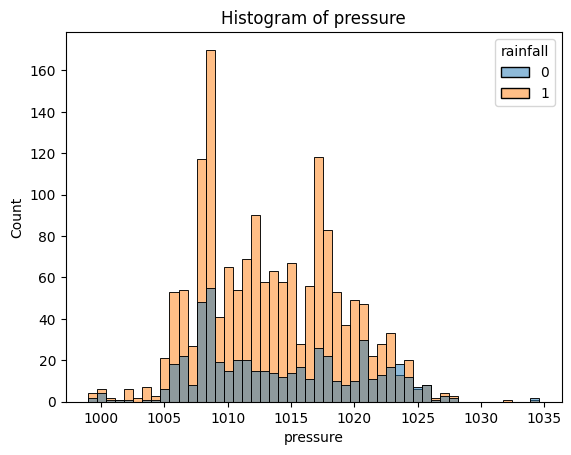

<Figure size 640x480 with 0 Axes>

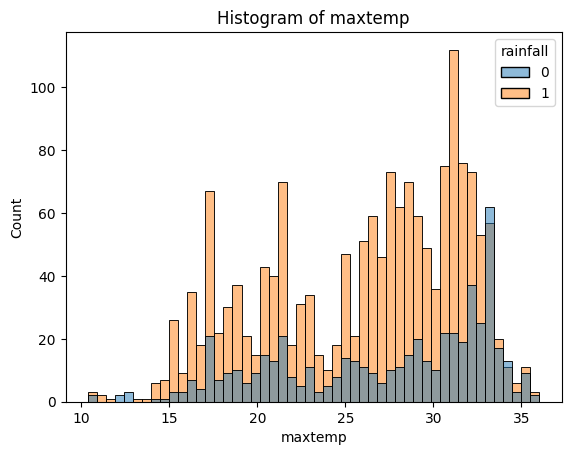

<Figure size 640x480 with 0 Axes>

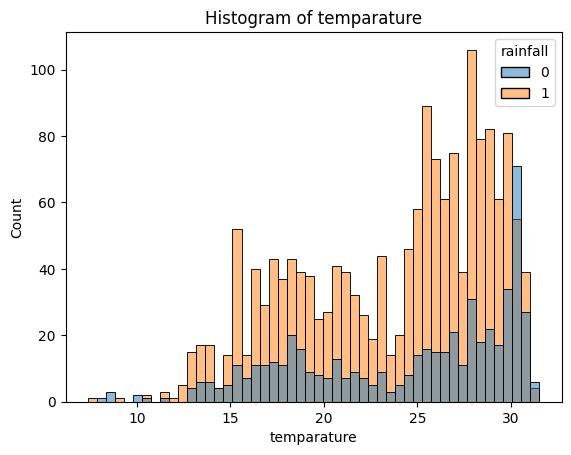

<Figure size 640x480 with 0 Axes>

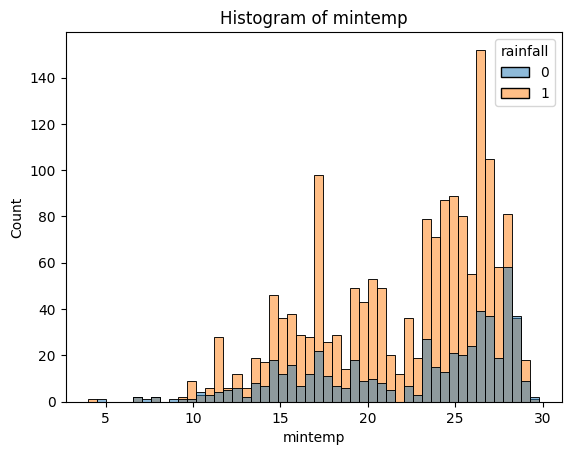

<Figure size 640x480 with 0 Axes>

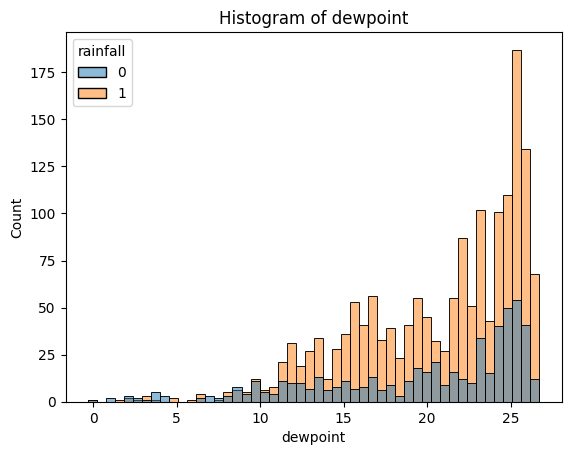

<Figure size 640x480 with 0 Axes>

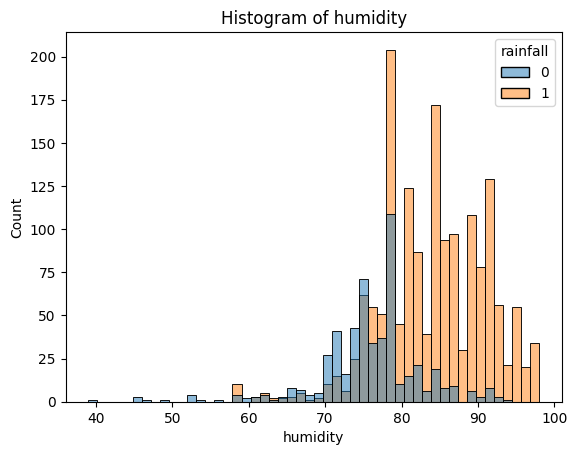

<Figure size 640x480 with 0 Axes>

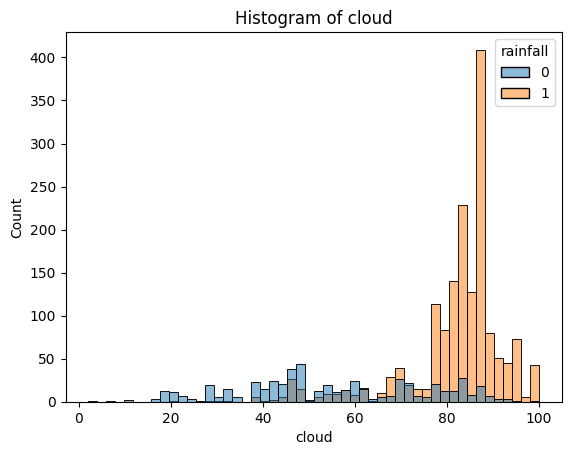

<Figure size 640x480 with 0 Axes>

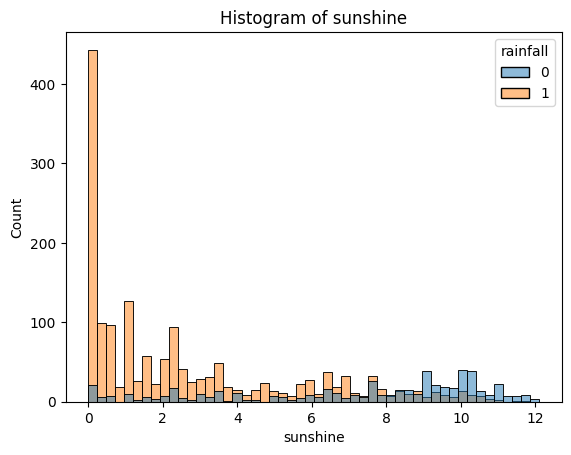

<Figure size 640x480 with 0 Axes>

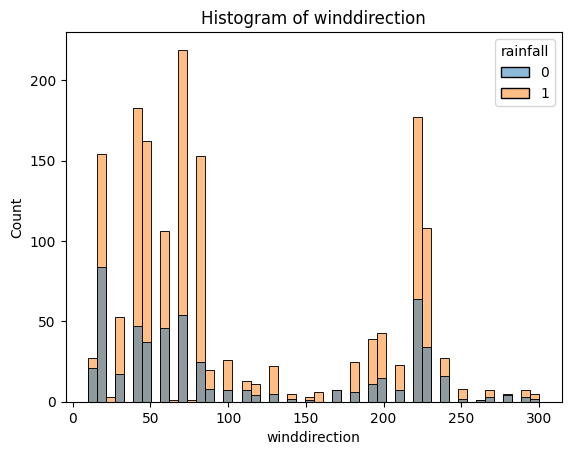

<Figure size 640x480 with 0 Axes>

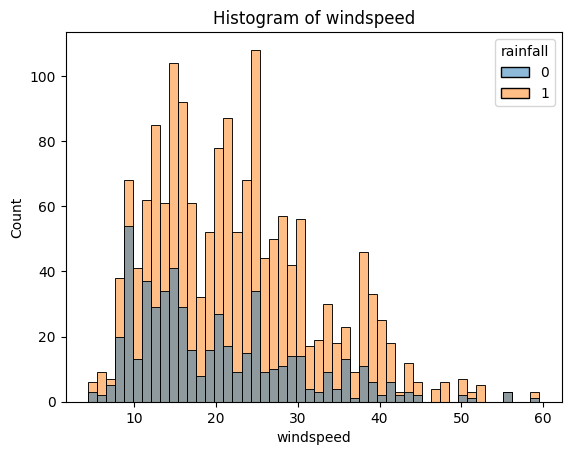

<Figure size 640x480 with 0 Axes>

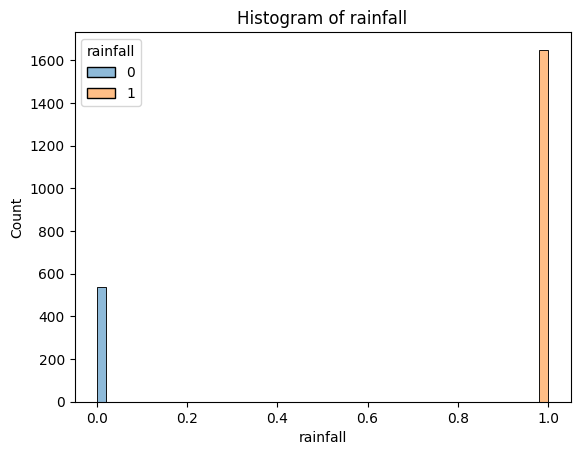

<Figure size 640x480 with 0 Axes>

In [9]:
for col in rainfall_train.columns:
    plt.figure()
    sns.histplot(data=rainfall_train,x=col,bins=50,hue='rainfall')
    plt.title(f"Histogram of {col}")
    plt.show()
    plt.clf()

One thing that is very noticeable is that there are roughly three times as many days with rainfall as there are days without rainfall. Furthermore many of the features are very skewed. We might have to transform the data in order to improve the model performance. Finally the features 'humidity', 'cloud' and 'sunshine' are interesting since we see there are cutoff points where the datapoints are either all rain or no rain. In fact there might be multiple cutoff points which could be worthwhile to play around with. For instance, when 'cloud' is above 80, the day is almost always rain but when 'cloud' is below 40, the day is almost always no rain.

Since the data appears to be time series data, let us plot the data with respect to the index.

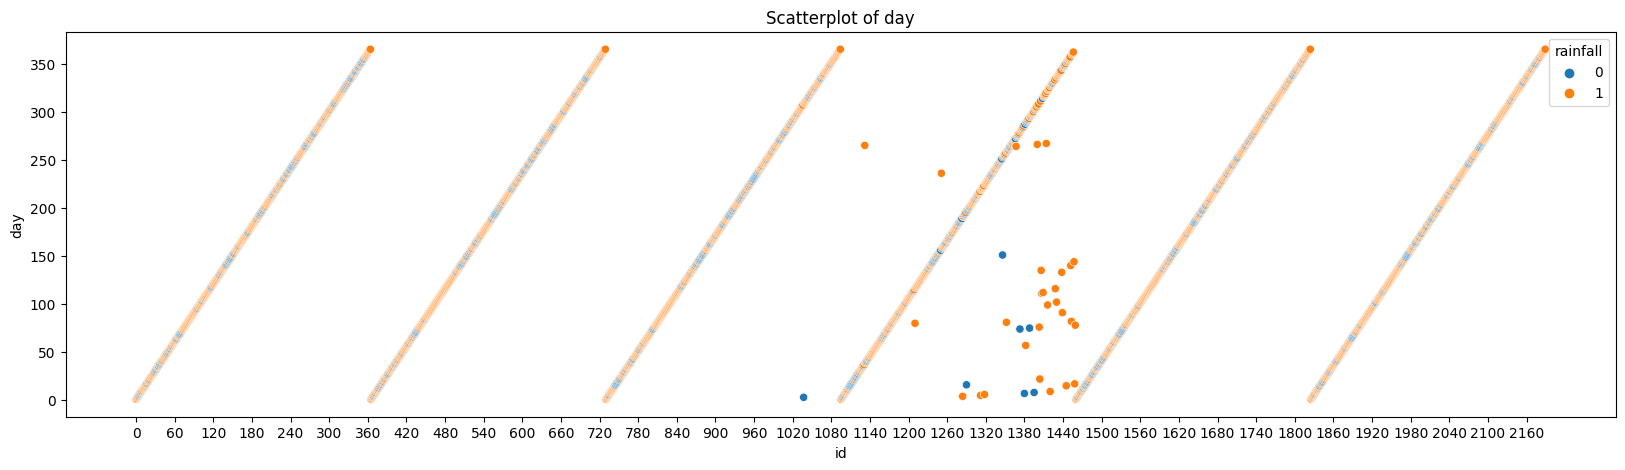

<Figure size 640x480 with 0 Axes>

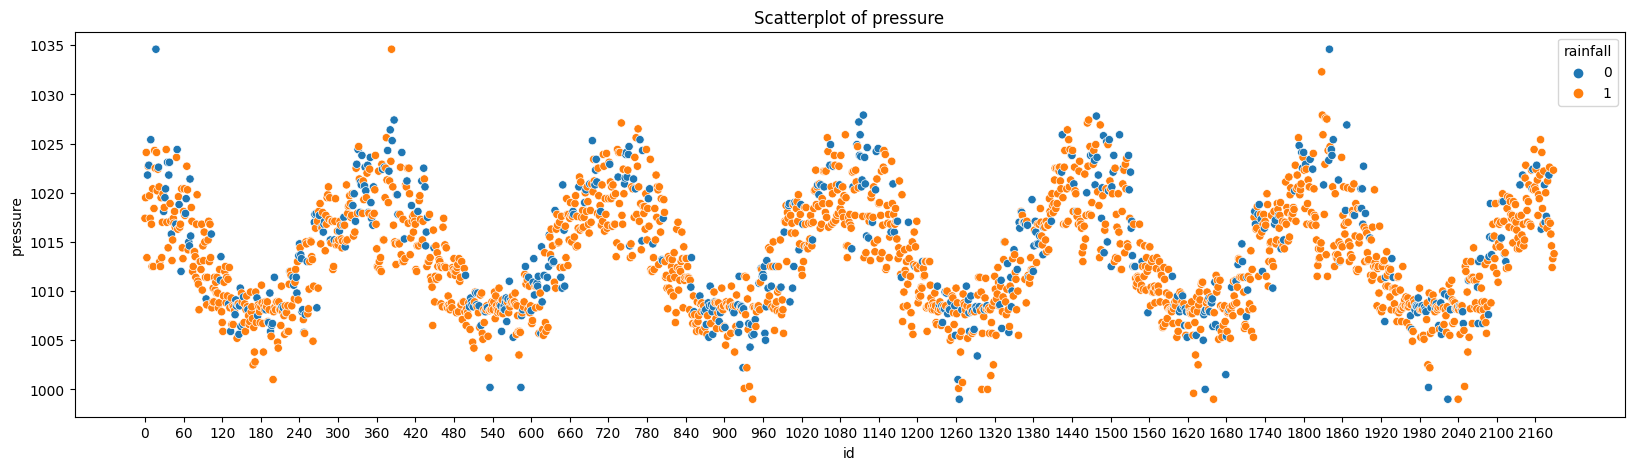

<Figure size 640x480 with 0 Axes>

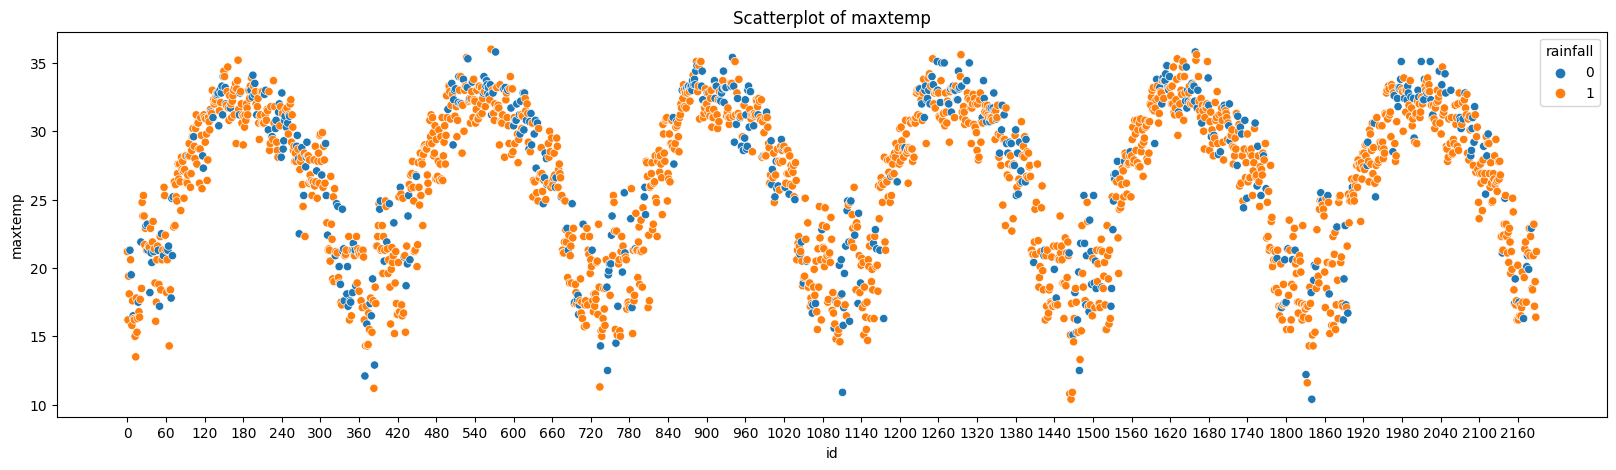

<Figure size 640x480 with 0 Axes>

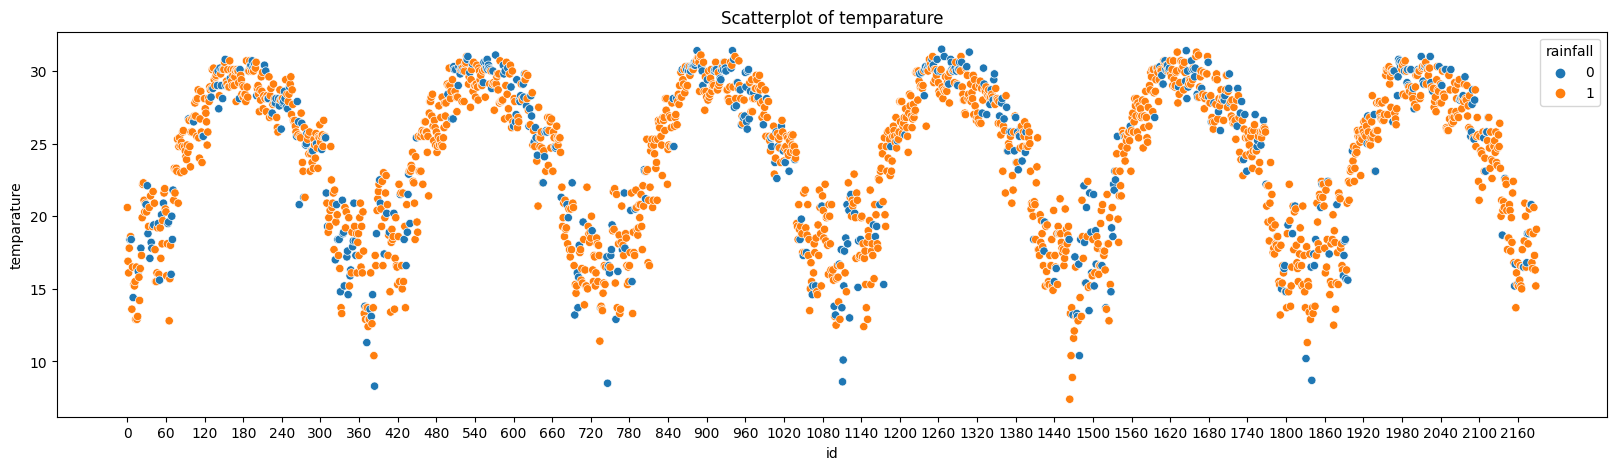

<Figure size 640x480 with 0 Axes>

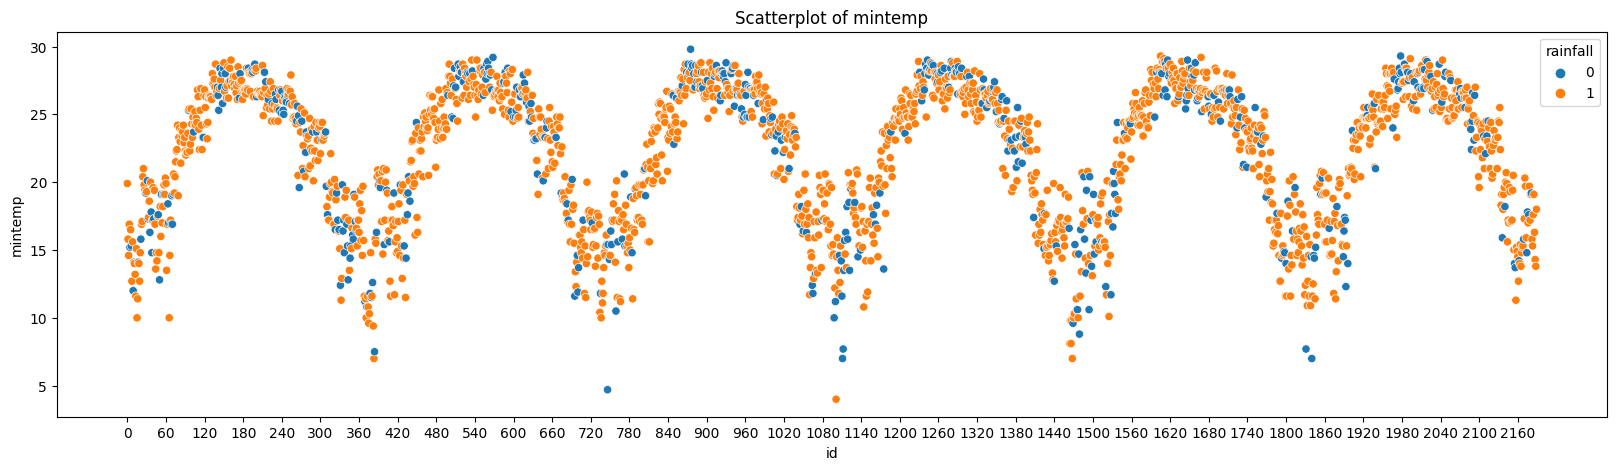

<Figure size 640x480 with 0 Axes>

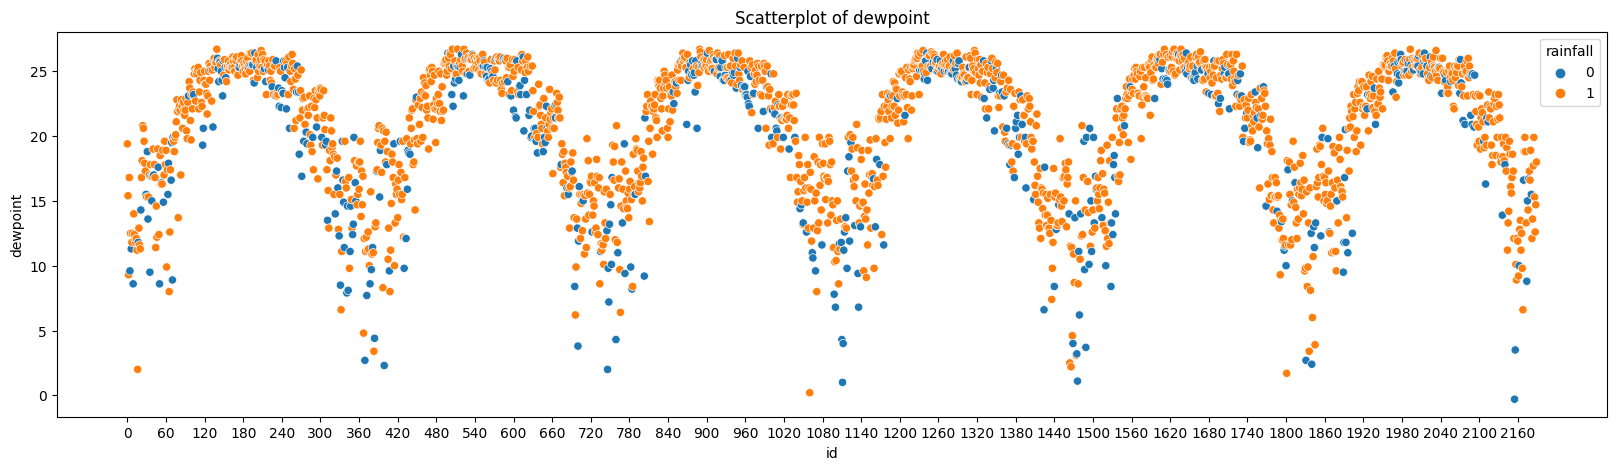

<Figure size 640x480 with 0 Axes>

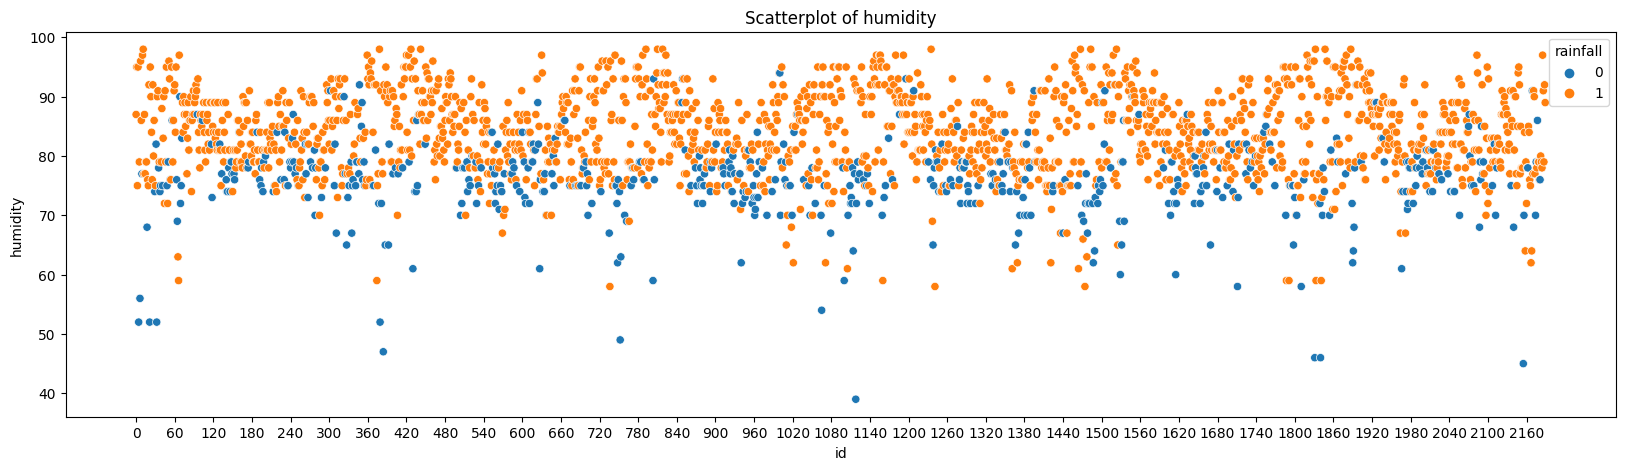

<Figure size 640x480 with 0 Axes>

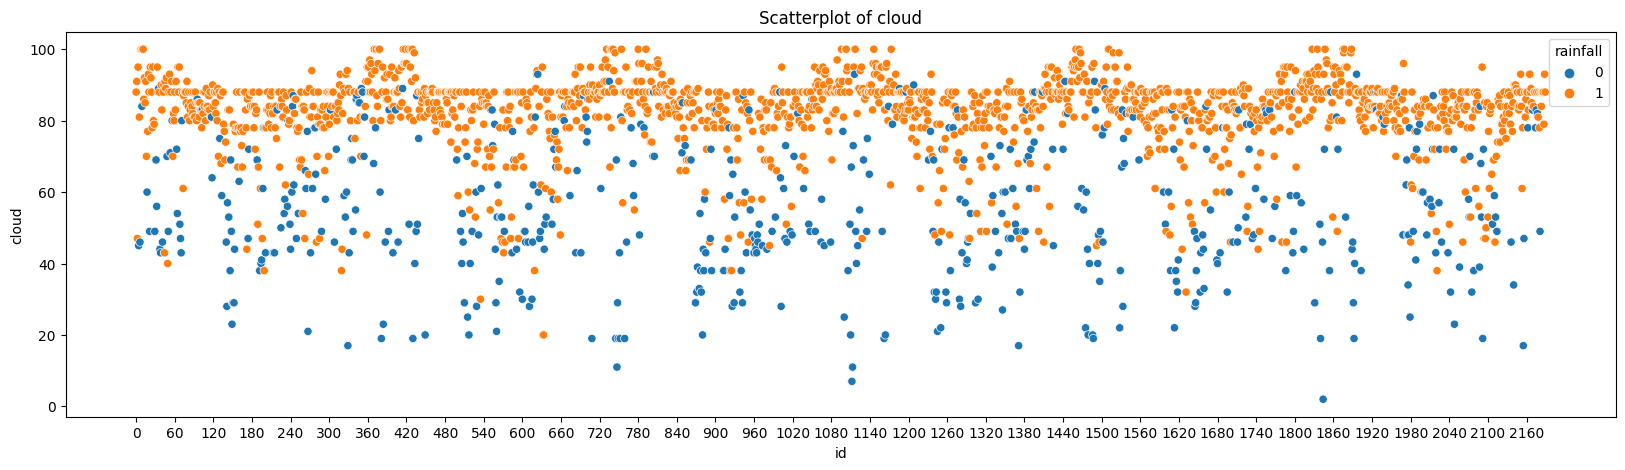

<Figure size 640x480 with 0 Axes>

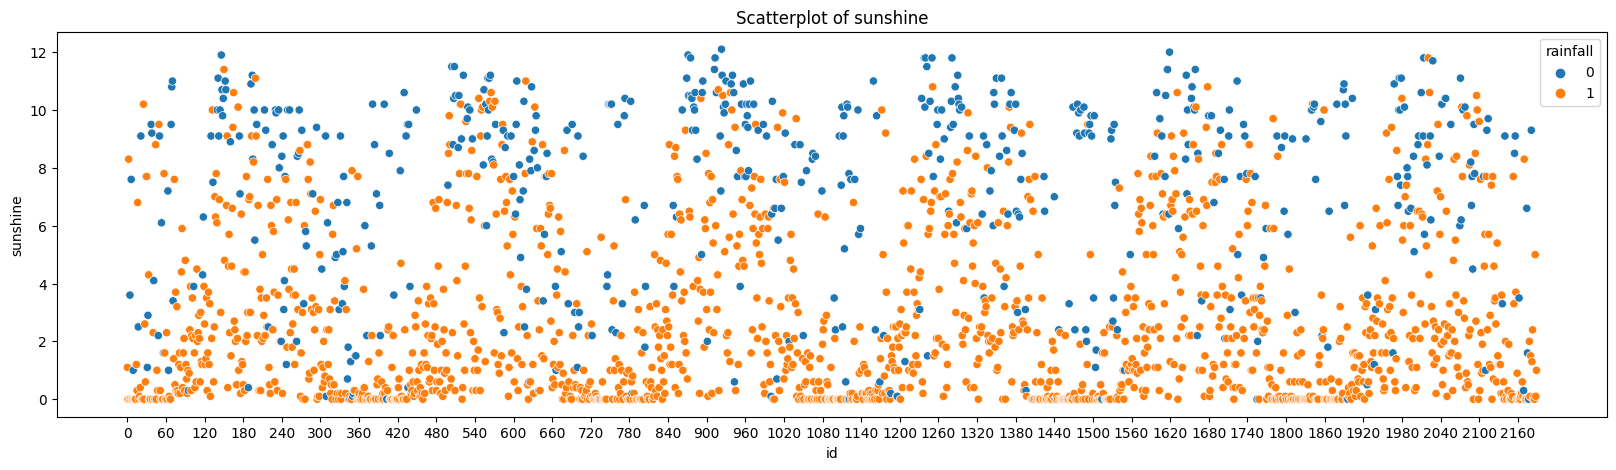

<Figure size 640x480 with 0 Axes>

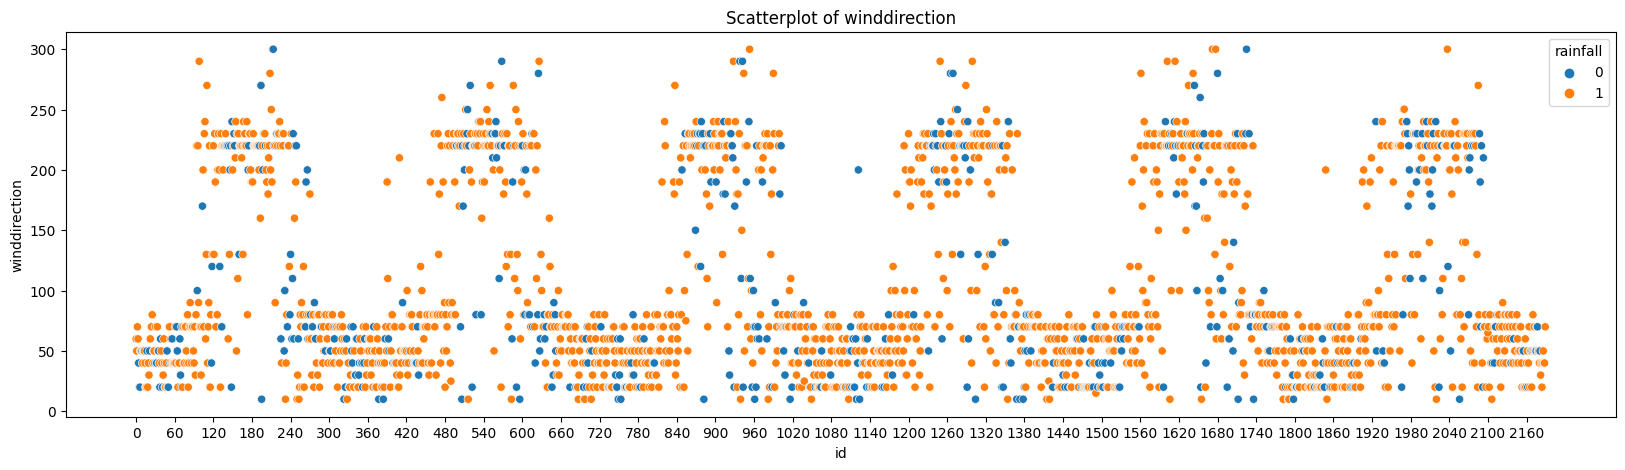

<Figure size 640x480 with 0 Axes>

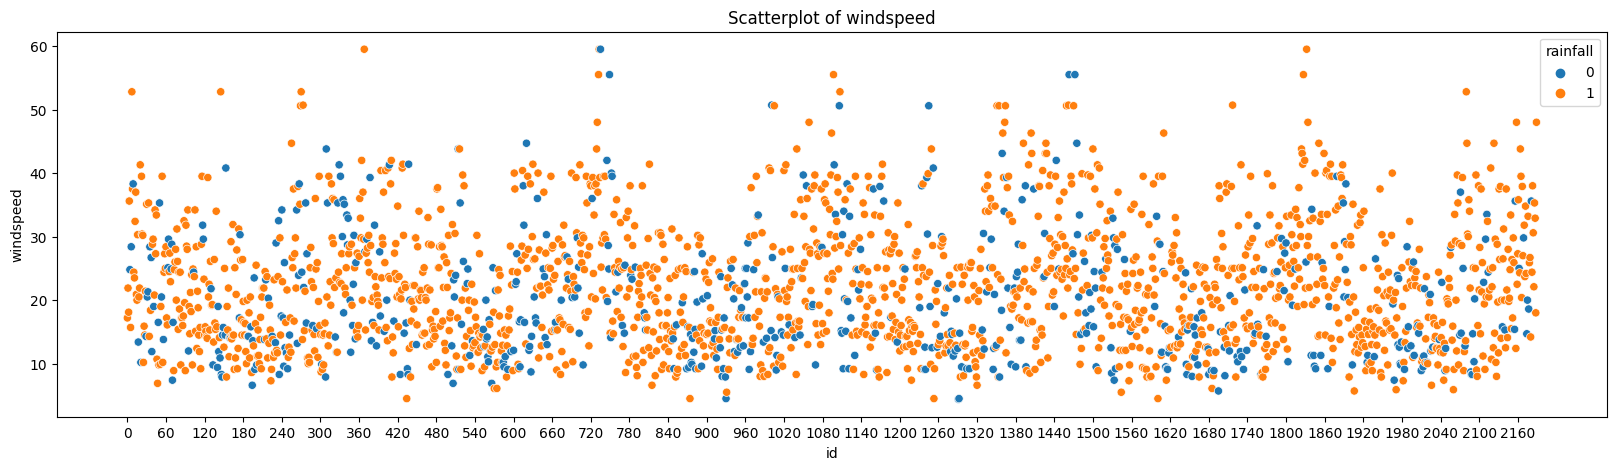

<Figure size 640x480 with 0 Axes>

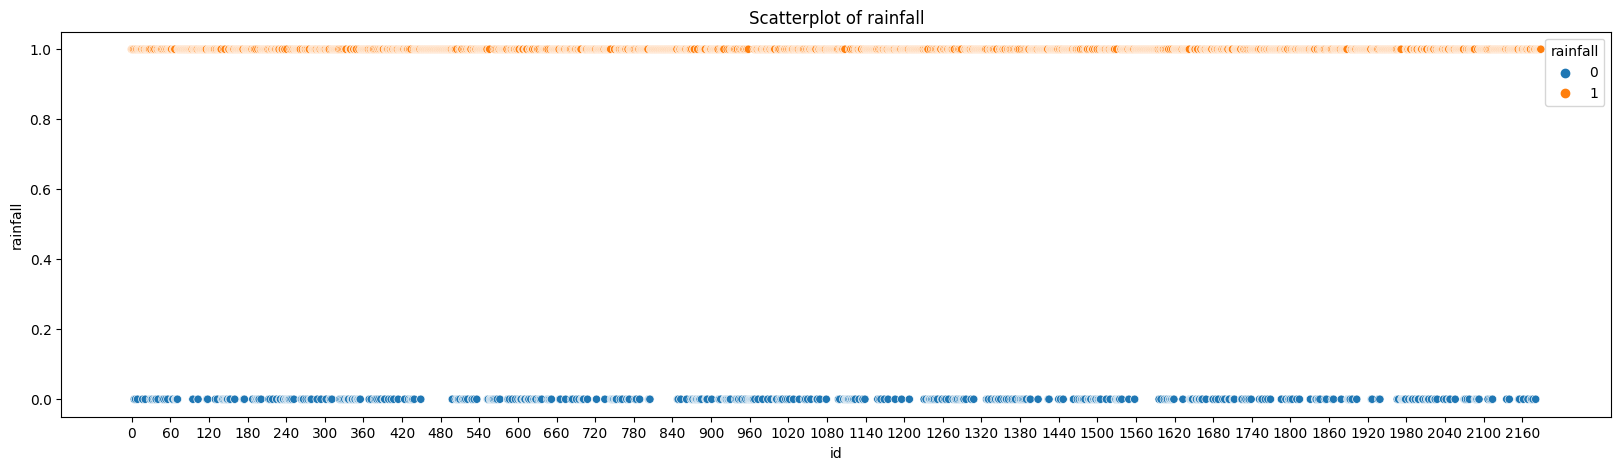

<Figure size 640x480 with 0 Axes>

In [10]:
for col in rainfall_train.columns:
    plt.figure(figsize=(20, 5))  
    sns.scatterplot(x=rainfall_train.index, y=col, data=rainfall_train, hue='rainfall')
    plt.xticks(range(0, len(rainfall_train.index), 60))
    plt.title(f"Scatterplot of {col}")
    plt.show()
    plt.clf()

We see that we have roughly 6 years of data and many of the features exhibit cyclical properties. However due to the synthetic nature of the data, some features like 'day' appear to be mislabeled. The rainfall scatterplot is really difficult to understand. This region seems to get rain yearlong but there appears rain season each year based on the gaps in the blue dots. It is hard to tell when it exactly is, but it appears that there gap occurs around 70-90 days into the year.

In [11]:
y_train = rainfall_train['rainfall']
X_train = rainfall_train.drop('rainfall',axis=1)
X_test = rainfall_test

Let's set up some pipelines. We will do some feature engineering as well as imputation and scaling. We will add shift and diff features to account for the time-series data as well as some cyclical features using 'day'. We will create a function that drops some of the most highly correlated features to possibly improve model performance. This will mostly matter for logistic regression. 

We will train both a logisitic regression model as well as an XGBoost Classifier model. 

In [12]:
def shift_features(df):
    for c in ['pressure', 'maxtemp', 'temparature', 'mintemp','dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection','windspeed']:
        if c != 'day':
            for gap in [1]:
                df[c+f"_shift{gap}"]=df[c].shift(gap)
                df[c+f"_diff{gap}"]=df[c].diff(gap)
    return df

def drop_features(df):
    return df.drop(columns=['temparature','maxtemp','mintemp'],axis=1)

def day_features(df):
    df['sin_day']=np.sin(2*np.pi*df['day']/365)
    df['cos_day']=np.cos(2*np.pi*df['day']/365)
    df['sin_day2']=np.sin(2*np.pi*df['day']/365/2)
    df['cos_day2']=np.cos(2*np.pi*df['day']/365/2)
    return df

shift_transformer = make_pipeline(
    FunctionTransformer(shift_features),
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

drop_transformer = make_pipeline(
    FunctionTransformer(drop_features),    
)

day_transformer = FunctionTransformer(day_features)

numerical_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('drop',drop_transformer,['temparature','maxtemp','mintemp']),
        ('day',day_transformer,['day']),
    ],remainder = numerical_transformer)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('shift',shift_transformer,['pressure', 'maxtemp', 'temparature', 'mintemp','dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection','windspeed']),
        ('day',day_transformer,['day']),
    ],remainder = numerical_transformer)

lr_pipeline = make_pipeline(
    preprocessor_lr,
    LogisticRegression(solver='liblinear', random_state=42)
)

xgb_pipeline = make_pipeline(
    preprocessor_xgb,
    XGBClassifier(random_state=42)
)

Let's train the models and check out the AUC metric.

Best parameters: {'logisticregression__C': 1}
Fold 1 AUC-ROC Score: 0.8909323116219668
Fold 2 AUC-ROC Score: 0.9158931082981716
Fold 3 AUC-ROC Score: 0.8952991452991453
Fold 4 AUC-ROC Score: 0.8945840891422648
Fold 5 AUC-ROC Score: 0.8827901309777643
Fold 6 AUC-ROC Score: 0.8845829315332691
Overall AUC-ROC Score: 0.8963019079685746


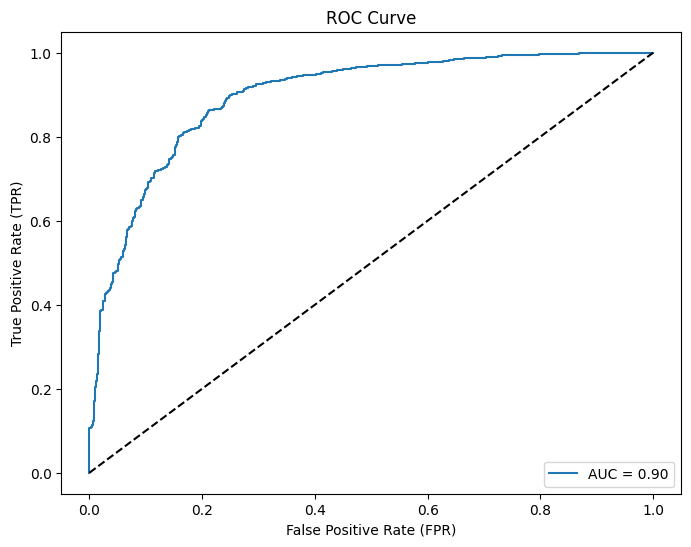

In [29]:
param_grid_lr = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1] 
}

tscv = TimeSeriesSplit(n_splits=6)

grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, scoring = 'roc_auc', cv= tscv)
grid_search_lr.fit(X_train, y_train)

print(f"Best parameters: {grid_search_lr.best_params_}")
best_pipeline_lr = grid_search_lr.best_estimator_

for i, (train_index, test_index) in enumerate(tscv.split(X_train)):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    best_pipeline_lr.fit(X_train_fold, y_train_fold)
    y_probs_fold = best_pipeline_lr.predict_proba(X_test_fold)[:, 1]
    auc_score_fold = roc_auc_score(y_test_fold, y_probs_fold)
    print(f"Fold {i+1} AUC-ROC Score: {auc_score_fold}")

y_probs_lr = best_pipeline_lr.predict_proba(X_train)[:, 1]
auc_score_lr = roc_auc_score(y_train, y_probs_lr)
print(f"Overall AUC-ROC Score: {auc_score_lr}")

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_train, y_probs_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'AUC = {auc_score_lr:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

y_probs_best_lr = best_pipeline_lr.predict_proba(X_test)[:, 1]  

Best parameters: {'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 200}
Fold 1 AUC-ROC Score: 0.8591060025542784
Fold 2 AUC-ROC Score: 0.8868073136427567
Fold 3 AUC-ROC Score: 0.904531010300241
Fold 4 AUC-ROC Score: 0.8840632288157554
Fold 5 AUC-ROC Score: 0.8755102040816326
Fold 6 AUC-ROC Score: 0.8780135004821601
Overall AUC-ROC Score: 0.9159001122334455


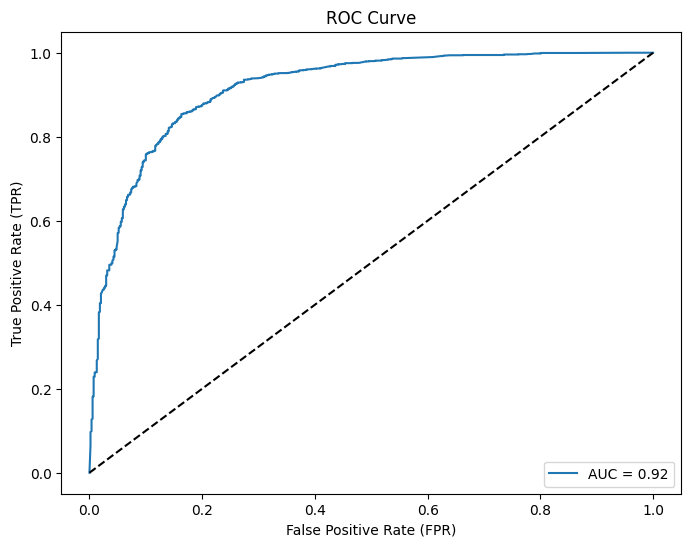

In [21]:
param_grid_xgb = {
    'xgbclassifier__n_estimators': [100, 150, 200],
    'xgbclassifier__learning_rate': [0.001, 0.01, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5]
}

tscv = TimeSeriesSplit(n_splits=6)


grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, scoring ='roc_auc', cv=tscv
)
grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters: {grid_search_xgb.best_params_}")
best_pipeline_xgb = grid_search_xgb.best_estimator_

for i, (train_index, test_index) in enumerate(tscv.split(X_train)):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    best_pipeline_xgb.fit(X_train_fold, y_train_fold)
    y_probs_fold = best_pipeline_xgb.predict_proba(X_test_fold)[:, 1]
    auc_score_fold = roc_auc_score(y_test_fold, y_probs_fold)
    print(f"Fold {i+1} AUC-ROC Score: {auc_score_fold}")

y_probs_xgb = best_pipeline_xgb.predict_proba(X_train)[:, 1]
auc_score_xgb = roc_auc_score(y_train, y_probs_xgb)
print(f"Overall AUC-ROC Score: {auc_score_xgb}")

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_train, y_probs_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'AUC = {auc_score_xgb:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

y_probs_best_xgb = best_pipeline_xgb.predict_proba(X_test)[:, 1]  

The XGBoost model appears to perform better than logisitic regression, but it also looks to be overfitting. The logistic regression is not that much worse, but the ROC-AUC score seems to be consistent across the folds. We will use this for our submission.

In [15]:
df = pd.DataFrame({'rainfall':y_probs_best_lr}) 
df.index = range(2190, 2920)
df.index.name = 'id'

In [16]:
df.to_csv('submission.csv') 

To improve our results, we can try to incorporate more feature engineering. We can also try a better cross-validation strategy that works better with the time series data. We might also want to try different models such as CatBoost and LightGBM. However since the dataset is small, we need to be careful of overfitting.